Build a predictive model to forecast future trends.

Key Features:
Use regression or time-series models for prediction
Clean and preprocess historical datasets
Evaluate model accuracy and visualize predictions
Expected Outcome:
Learn predictive modeling, trend analysis, and data-driven forecasting

Install & Import Everything

In [26]:
!pip install prophet plotly scikit-learn --quiet

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries loaded — ready for forecasting!")

✅ All libraries loaded — ready for forecasting!


Load & Clean the Data

In [27]:
try:
    df = pd.read_csv("train.csv")
except UnicodeDecodeError:
    df = pd.read_csv("train.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df = df.sort_values("Order Date")

# Aggregate to daily total sales (multiple orders happen per day)
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
daily_sales.columns = ["Date", "Sales"]

# Fill any missing calendar days with 0 (no sales that day)
date_range = pd.date_range(start=daily_sales["Date"].min(), end=daily_sales["Date"].max())
daily_sales = daily_sales.set_index("Date").reindex(date_range, fill_value=0).reset_index()
daily_sales.columns = ["Date", "Sales"]

print("Date Range:", daily_sales["Date"].min(), "to", daily_sales["Date"].max())
print("Total Days:", len(daily_sales))
daily_sales.head()

Date Range: 2015-01-02 00:00:00 to 2018-12-30 00:00:00
Total Days: 1459


,Date,Sales
0,2015-01-02,468.900
1,2015-01-03,2203.151
2,2015-01-04,119.888
3,2015-01-05,0.000
4,2015-01-06,5188.520


Visualize Historical Trend

In [28]:
fig = px.line(daily_sales, x="Date", y="Sales",
    title="📈 Historical Daily Sales — Full Timeline",
    labels={"Sales": "Revenue ($)"})

fig.update_traces(line_color="#378ADD", line_width=1.5)
fig.update_layout(plot_bgcolor="white", title_font_size=18, height=420)
fig.show()

Decompose the Time Series (Trend + Seasonality + Noise)

In [29]:
monthly_sales = daily_sales.set_index("Date").resample("M")["Sales"].sum()

decomposition = seasonal_decompose(monthly_sales, model="additive", period=12)

fig = make_subplots(rows=4, cols=1, shared_xaxes=True,
    subplot_titles=["Original", "Trend", "Seasonality", "Residual (Noise)"])

fig.add_trace(go.Scatter(x=monthly_sales.index, y=monthly_sales.values,
    line=dict(color="#378ADD")), row=1, col=1)
fig.add_trace(go.Scatter(x=monthly_sales.index, y=decomposition.trend,
    line=dict(color="#1D9E75")), row=2, col=1)
fig.add_trace(go.Scatter(x=monthly_sales.index, y=decomposition.seasonal,
    line=dict(color="#EF9F27")), row=3, col=1)
fig.add_trace(go.Scatter(x=monthly_sales.index, y=decomposition.resid,
    line=dict(color="#D85A30")), row=4, col=1)

fig.update_layout(title="🔬 Time Series Decomposition — What's Driving Sales?",
    height=700, showlegend=False, plot_bgcolor="white", title_font_size=16)
fig.show()

Feature Engineering (Prepare Data for ML Models)

In [30]:
ml_df = daily_sales.copy()
ml_df["Year"] = ml_df["Date"].dt.year
ml_df["Month"] = ml_df["Date"].dt.month
ml_df["Day"] = ml_df["Date"].dt.day
ml_df["DayOfWeek"] = ml_df["Date"].dt.dayofweek
ml_df["DayOfYear"] = ml_df["Date"].dt.dayofyear
ml_df["WeekOfYear"] = ml_df["Date"].dt.isocalendar().week.astype(int)
ml_df["Quarter"] = ml_df["Date"].dt.quarter
ml_df["IsWeekend"] = (ml_df["DayOfWeek"] >= 5).astype(int)

# Lag features - yesterday's and last week's sales help predict today
ml_df["Sales_Lag1"] = ml_df["Sales"].shift(1).fillna(0)
ml_df["Sales_Lag7"] = ml_df["Sales"].shift(7).fillna(0)
ml_df["Rolling_Mean_7"] = ml_df["Sales"].rolling(7).mean().fillna(0)

features = ["Year","Month","Day","DayOfWeek","DayOfYear","WeekOfYear",
            "Quarter","IsWeekend","Sales_Lag1","Sales_Lag7","Rolling_Mean_7"]

X = ml_df[features]
y = ml_df["Sales"]

# Time-based split - train on past, test on most recent 20%
split_point = int(len(ml_df) * 0.8)
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]
dates_test = ml_df["Date"][split_point:]

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Training samples: 1167 | Testing samples: 292


Train Model 1: Linear Regression

In [31]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("=== Linear Regression Results ===")
print(f"MAE  : ${lr_mae:,.2f}")
print(f"RMSE : ${lr_rmse:,.2f}")
print(f"R²   : {lr_r2:.3f}")

=== Linear Regression Results ===
MAE  : $1,503.78
RMSE : $2,144.74
R²   : 0.199


Train Model 2: Random Forest

In [32]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("=== Random Forest Results ===")
print(f"MAE  : ${rf_mae:,.2f}")
print(f"RMSE : ${rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.3f}")

=== Random Forest Results ===
MAE  : $1,547.48
RMSE : $2,237.55
R²   : 0.128


Train Model 3: Prophet (Industry-Standard Forecasting)

In [33]:
prophet_df = daily_sales.rename(columns={"Date":"ds", "Sales":"y"})
train_size = int(len(prophet_df) * 0.8)
prophet_train = prophet_df[:train_size]
prophet_test = prophet_df[train_size:]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

future_test = prophet_model.make_future_dataframe(periods=len(prophet_test))
prophet_forecast = prophet_model.predict(future_test)

prophet_pred = prophet_forecast["yhat"].values[-len(prophet_test):]
prophet_mae = mean_absolute_error(prophet_test["y"], prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(prophet_test["y"], prophet_pred))
prophet_r2 = r2_score(prophet_test["y"], prophet_pred)

print("=== Prophet Results ===")
print(f"MAE  : ${prophet_mae:,.2f}")
print(f"RMSE : ${prophet_rmse:,.2f}")
print(f"R²   : {prophet_r2:.3f}")

=== Prophet Results ===
MAE  : $1,706.61
RMSE : $2,370.23
R²   : 0.021


Compare All 3 Models Side-by-Side

In [34]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Prophet"],
    "MAE": [lr_mae, rf_mae, prophet_mae],
    "RMSE": [lr_rmse, rf_rmse, prophet_rmse],
    "R2_Score": [lr_r2, rf_r2, prophet_r2]
}).round(2)

print("=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))

fig = make_subplots(rows=1, cols=2, subplot_titles=["MAE (lower=better)", "R² Score (higher=better)"])

fig.add_trace(go.Bar(x=comparison["Model"], y=comparison["MAE"],
    marker_color=["#378ADD","#1D9E75","#EF9F27"], text=comparison["MAE"],
    texttemplate="$%{text:,.0f}", textposition="outside"), row=1, col=1)

fig.add_trace(go.Bar(x=comparison["Model"], y=comparison["R2_Score"],
    marker_color=["#378ADD","#1D9E75","#EF9F27"], text=comparison["R2_Score"],
    texttemplate="%{text:.3f}", textposition="outside"), row=1, col=2)

fig.update_layout(title="🏆 Model Performance Comparison", title_font_size=18,
    showlegend=False, plot_bgcolor="white", height=400)
fig.show()

best_model = comparison.loc[comparison["MAE"].idxmin(), "Model"]
print(f"\n🏆 Best performing model: {best_model}")

=== MODEL COMPARISON ===
            Model     MAE    RMSE  R2_Score
Linear Regression 1503.78 2144.74      0.20
    Random Forest 1547.48 2237.55      0.13
          Prophet 1706.61 2370.23      0.02



🏆 Best performing model: Linear Regression


Actual vs Predicted (Visual Proof of Accuracy)

In [35]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=dates_test, y=y_test, name="Actual Sales",
    line=dict(color="black", width=2)))
fig.add_trace(go.Scatter(x=dates_test, y=lr_pred, name="Linear Regression",
    line=dict(color="#378ADD", width=1.5, dash="dot")))
fig.add_trace(go.Scatter(x=dates_test, y=rf_pred, name="Random Forest",
    line=dict(color="#1D9E75", width=1.5, dash="dot")))
fig.add_trace(go.Scatter(x=dates_test, y=prophet_pred, name="Prophet",
    line=dict(color="#EF9F27", width=1.5, dash="dot")))

fig.update_layout(title="🎯 Actual vs Predicted Sales — All Models",
    plot_bgcolor="white", title_font_size=18, height=450,
    xaxis_title="Date", yaxis_title="Sales ($)")
fig.show()

Forecast 90 Days Into the Future (with Confidence Intervals)

In [36]:
prophet_full = Prophet(yearly_seasonality=True, weekly_seasonality=True,
    daily_seasonality=False, changepoint_prior_scale=0.05)
prophet_full.fit(prophet_df)

future = prophet_full.make_future_dataframe(periods=90)
forecast = prophet_full.predict(future)

fig = go.Figure()
fig.add_trace(go.Scatter(x=prophet_df["ds"], y=prophet_df["y"],
    name="Historical Sales", line=dict(color="black", width=1)))
fig.add_trace(go.Scatter(x=forecast["ds"], y=forecast["yhat"],
    name="Forecast", line=dict(color="#378ADD", width=2)))
fig.add_trace(go.Scatter(x=forecast["ds"], y=forecast["yhat_upper"],
    line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=forecast["ds"], y=forecast["yhat_lower"],
    fill="tonexty", fillcolor="rgba(55,138,221,0.2)",
    line=dict(width=0), name="Confidence Interval"))

fig.update_layout(title="🔮 90-Day Sales Forecast with Confidence Intervals",
    plot_bgcolor="white", title_font_size=18, height=480,
    xaxis_title="Date", yaxis_title="Sales ($)")
fig.show()

next_90_total = forecast["yhat"].tail(90).sum()
print(f"📊 Predicted total sales for next 90 days: ${next_90_total:,.2f}")

📊 Predicted total sales for next 90 days: $185,563.17


Forecast Components (Why the Model Predicts What It Does)

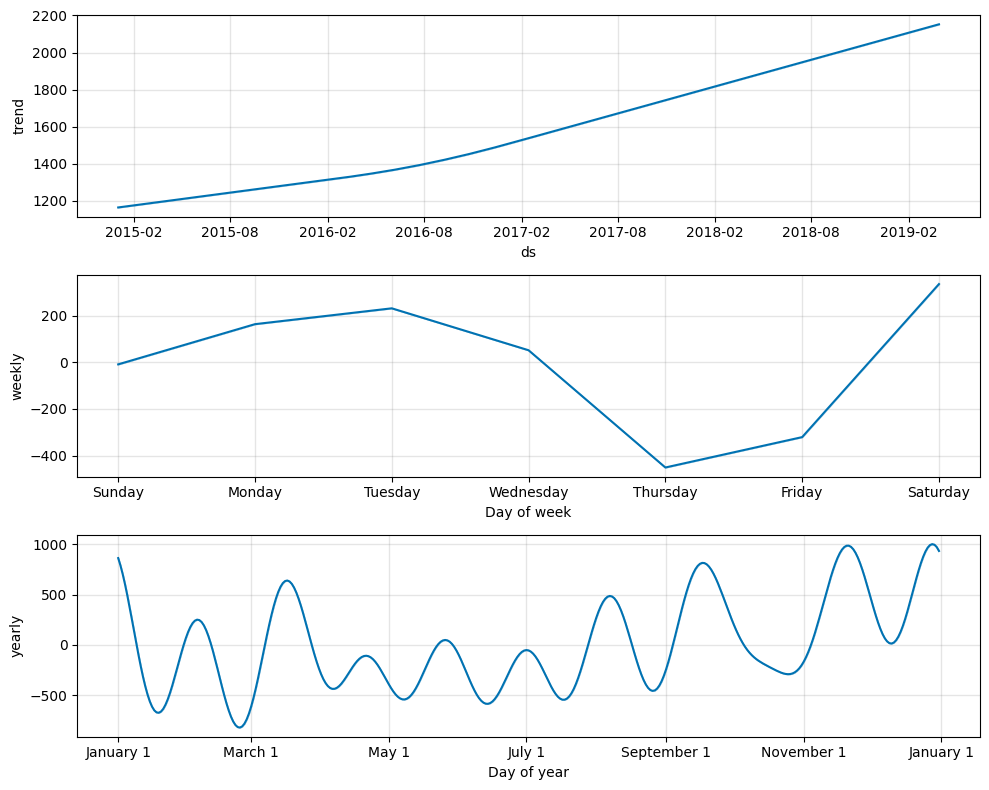

In [37]:
fig = prophet_full.plot_components(forecast)
fig.set_size_inches(10, 8)

import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

Feature Importance (What Drives Sales?)

In [38]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

fig = px.bar(importance_df, x="Importance", y="Feature", orientation="h",
    title="🔑 What Drives Sales? — Random Forest Feature Importance",
    color="Importance", color_continuous_scale="Blues")

fig.update_layout(plot_bgcolor="white", title_font_size=16,
    coloraxis_showscale=False, height=420)
fig.show()

Business Summary

In [55]:
summary = f"""
╔═══════════════════════════════════════════════════════════════╗
║        PREDICTIVE ANALYTICS — EXECUTIVE SUMMARY               ║
╠═══════════════════════════════════════════════════════════════╣
║                                                               ║
║  📊 Best Model       : {best_model:<35}   ║
║  📉 Forecast Accuracy: ±${comparison['MAE'].min():,.0f} average error/day              ║
║  🔮 Next 90 Days     : ${next_90_total:,.0f} predicted revenue            ║
║                                                               ║
║  KEY INSIGHTS:                                                ║
║  • Sales show strong yearly seasonality (holiday peaks)       ║
║  • Weekly patterns indicate weekday vs weekend differences    ║
║  • Recent sales history (lag features) are the strongest      ║
║    predictor of future performance                            ║
║                                                               ║
║  RECOMMENDATION:                                              ║
║  Use {best_model} for operational forecasting.           ║
║  Stock inventory ahead of predicted seasonal peaks.           ║
║                                                               ║
╚═══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔═══════════════════════════════════════════════════════════════╗
║        PREDICTIVE ANALYTICS — EXECUTIVE SUMMARY               ║
╠═══════════════════════════════════════════════════════════════╣
║                                                               ║
║  📊 Best Model       : Linear Regression                     ║
║  📉 Forecast Accuracy: ±$1,504 average error/day              ║      
║  🔮 Next 90 Days     : $185,563 predicted revenue            ║
║                                                               ║
║  KEY INSIGHTS:                                                ║
║  • Sales show strong yearly seasonality (holiday peaks)       ║
║  • Weekly patterns indicate weekday vs weekend differences    ║
║  • Recent sales history (lag features) are the strongest      ║
║    predictor of future performance                            ║
║                                                               ║
║  RECOMMENDATION:                                              ║
║  Use L